In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

importing the libraries

In [82]:
df = pd.read_csv("/Users/dhruvsingh/Desktop/datasupplychain/DataCoSupplyChainDataset.csv", encoding_errors="ignore")

In [114]:
df.head(10)

,type,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_day_of_week,order_hour,shipping_delay,net_unit_price,profit_margin_pct,order_year_month,order_quarter,is_late,is_fraud,market_region
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Wednesday,22,-1,314.640015,27.841342,2018-01,1,0,0,Pacific Asia - Southeast Asia
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Saturday,12,1,311.359985,-75.999999,2018-01,1,1,0,Pacific Asia - South Asia
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Saturday,12,0,309.720001,-75.600305,2018-01,1,0,0,Pacific Asia - South Asia
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Saturday,11,-1,304.809998,6.974829,2018-01,1,0,0,Pacific Asia - Oceania
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Saturday,11,-2,298.250000,40.948896,2018-01,1,0,0,Pacific Asia - Oceania
5,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,Saturday,11,2,294.980011,5.668955,2018-01,1,1,0,Pacific Asia - Oceania
6,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,Saturday,10,1,288.420013,29.040427,2018-01,1,1,0,Pacific Asia - Eastern Asia
7,TRANSFER,2,1,68.430000,285.140015,Late delivery,1,73,Sporting Goods,Miami,...,Saturday,10,1,285.140015,20.878719,2018-01,1,1,0,Pacific Asia - Eastern Asia
8,CASH,3,2,133.720001,278.589996,Late delivery,1,73,Sporting Goods,Caguas,...,Saturday,10,1,278.589996,40.799390,2018-01,1,1,0,Pacific Asia - Eastern Asia
9,CASH,2,1,132.149994,275.309998,Late delivery,1,73,Sporting Goods,San Ramon,...,Saturday,9,1,275.309998,40.320364,2018-01,1,1,0,Pacific Asia - Eastern Asia


In [113]:
df.shape

(180519, 60)

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 60 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   type                           180519 non-null  str           
 1   days_for_shipping_(real)       180519 non-null  int64         
 2   days_for_shipment_(scheduled)  180519 non-null  int64         
 3   benefit_per_order              180519 non-null  float64       
 4   sales_per_customer             180519 non-null  float64       
 5   delivery_status                180519 non-null  str           
 6   late_delivery_risk             180519 non-null  int64         
 7   category_id                    180519 non-null  int64         
 8   category_name                  180519 non-null  str           
 9   customer_city                  180519 non-null  str           
 10  customer_country               180519 non-null  str           
 11  customer_fn

In [111]:
df.describe().all

<bound method DataFrame.all of        days_for_shipping_(real)  days_for_shipment_(scheduled)  \
count             180519.000000                  180519.000000   
mean                   3.497654                       2.931847   
min                    0.000000                       0.000000   
25%                    2.000000                       2.000000   
50%                    3.000000                       4.000000   
75%                    5.000000                       4.000000   
max                    6.000000                       4.000000   
std                    1.623722                       1.374449   

       benefit_per_order  sales_per_customer  late_delivery_risk  \
count      180519.000000       180519.000000       180519.000000   
mean           21.974989          183.107609            0.548291   
min         -4274.979980            7.490000            0.000000   
25%             7.000000          104.379997            0.000000   
50%            31.520000          

In [110]:
df.describe()

,days_for_shipping_(real),days_for_shipment_(scheduled),benefit_per_order,sales_per_customer,late_delivery_risk,category_id,customer_id,customer_zipcode,department_id,latitude,...,shipping_date_(dateorders),order_year,order_month,order_hour,shipping_delay,net_unit_price,profit_margin_pct,order_quarter,is_late,is_fraud
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35920.529950,5.443460,29.719955,...,2016-06-16 05:45:23.202433,2015.971150,6.235449,11.483689,0.565807,126.908898,10.832612,2.417319,0.572793,0.022502
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,0.000000,2.000000,-33.937553,...,2015-01-03 00:00:00,2015.000000,1.000000,0.000000,-2.000000,7.490000,-274.999998,1.000000,0.000000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,2015-09-25 06:59:00,2015.000000,3.000000,5.000000,0.000000,45.000000,6.224000,1.000000,0.000000,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,2016-06-15 08:32:00,2016.000000,6.000000,11.000000,1.000000,59.990002,24.251212,2.000000,1.000000,0.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,2017-03-04 21:29:00,2017.000000,9.000000,17.000000,1.000000,179.990005,33.601431,3.000000,1.000000,0.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,2018-02-06 22:14:00,2018.000000,12.000000,23.000000,4.000000,1939.989990,50.044288,4.000000,1.000000,1.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.434755,1.629246,9.813646,...,NaN,0.829429,3.403571,6.923006,1.490966,126.299501,42.059372,1.096876,0.494674,0.148309


In [109]:
df.duplicated().sum()

np.int64(0)

In [108]:
df.isnull().sum()

type                             0
days_for_shipping_(real)         0
days_for_shipment_(scheduled)    0
benefit_per_order                0
sales_per_customer               0
delivery_status                  0
late_delivery_risk               0
category_id                      0
category_name                    0
customer_city                    0
customer_country                 0
customer_fname                   0
customer_id                      0
customer_lname                   0
customer_segment                 0
customer_state                   0
customer_street                  0
customer_zipcode                 0
department_id                    0
department_name                  0
latitude                         0
longitude                        0
market                           0
order_city                       0
order_country                    0
order_customer_id                0
order_date_(dateorders)          0
order_id                         0
order_item_cardprod_

In [107]:
df.ndim

2

In [106]:
df.columns

Index(['type', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_fname', 'customer_id', 'customer_lname',
       'customer_segment', 'customer_state', 'customer_street',
       'customer_zipcode', 'department_id', 'department_name', 'latitude',
       'longitude', 'market', 'order_city', 'order_country',
       'order_customer_id', 'order_date_(dateorders)', 'order_id',
       'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_card_id', 'product_category_id',
       'product_name', 'product_price', 'shipping_date_(dateorders)',
       'shi

DATA CLEANING

In [93]:
df.columns = df.columns.str.replace(" ", "_").str.lower()

In [94]:
# dropping columns that are not needed for analysis
cols_to_drop = [
    'product_description',
    'customer_email',
    'customer_password',
    'product_image',
    'product_status'
]

df.drop(columns = cols_to_drop, inplace = True)

In [95]:
# handling missing values 
df.drop(columns=['order_zipcode'], inplace = True)

In [96]:
df['customer_lname'] = df['customer_lname'].fillna('Unknown')
df['customer_zipcode'] = df['customer_zipcode'].fillna(0)


In [97]:
# combining the customer first name and the last name to create a full name column
df['customer_fullname'] = df['customer_fname'] + ' ' + df['customer_lname']

In [98]:
# 1. Convert the renamed date columns to datetime objects
df['order_date_(dateorders)'] = pd.to_datetime(df['order_date_(dateorders)'])
df['shipping_date_(dateorders)'] = pd.to_datetime(df['shipping_date_(dateorders)'])

# 2. Extract useful time features
# This helps in identifying seasonal trends or weekday patterns
df['order_year'] = df['order_date_(dateorders)'].dt.year
df['order_month'] = df['order_date_(dateorders)'].dt.month
df['order_day_of_week'] = df['order_date_(dateorders)'].dt.day_name()
df['order_hour'] = df['order_date_(dateorders)'].dt.hour

# 3. Create a clean 'shipping_delay' column using the new headers
# (Actual days - Scheduled days)
df['shipping_delay'] = df['days_for_shipping_(real)'] - df['days_for_shipment_(scheduled)']

# Verify the changes
print(df[['order_date_(dateorders)', 'order_day_of_week', 'shipping_delay']].head())

  order_date_(dateorders) order_day_of_week  shipping_delay
0     2018-01-31 22:56:00         Wednesday              -1
1     2018-01-13 12:27:00          Saturday               1
2     2018-01-13 12:06:00          Saturday               0
3     2018-01-13 11:45:00          Saturday              -1
4     2018-01-13 11:24:00          Saturday              -2


In [99]:
# calculating shipping delays
df['shipping_delay'] = df['days_for_shipping_(real)'] - df['days_for_shipment_(scheduled)']

print(df[['shipping_delay', 'days_for_shipping_(real)', 'days_for_shipment_(scheduled)']].head(10))


   shipping_delay  days_for_shipping_(real)  days_for_shipment_(scheduled)
0              -1                         3                              4
1               1                         5                              4
2               0                         4                              4
3              -1                         3                              4
4              -2                         2                              4
5               2                         6                              4
6               1                         2                              1
7               1                         2                              1
8               1                         3                              2
9               1                         2                              1


In [100]:
# Net price - the actual price paid by the customer after discounts and promotions
df['net_unit_price'] = df['order_item_total'] / df['order_item_quantity']


In [101]:
# profit margin percentage
df['profit_margin_pct'] = (df['benefit_per_order'] / df['sales']).fillna(0) * 100

In [102]:
#  Year-Month String (e.g., "2017-05")
df['order_year_month'] = df['order_date_(dateorders)'].dt.to_period('M').astype(str)

#  Quarter
df['order_quarter'] = df['order_date_(dateorders)'].dt.quarter

#  Delivery Performance Flag
# 1 if the package was late, 0 if on time or early
df['is_late'] = (df['days_for_shipping_(real)'] > df['days_for_shipment_(scheduled)']).astype(int)

In [103]:
# fraud flag - 1 if the order status is 'SUSPECTED_FRAUD', otherwise 0
df['is_fraud'] = (df['order_status'] == 'SUSPECTED_FRAUD').astype(int)

In [104]:
df['is_fraud'].value_counts() # 1 if fraud, 0 is not fraud

is_fraud
0    176457
1      4062
Name: count, dtype: int64

In [105]:
# market region hierarchy
# 9. Market-Region Hierarchy
df['market_region'] = df['market'] + " - " + df['order_region']

df['market_region'].head(10)

0    Pacific Asia - Southeast Asia
1        Pacific Asia - South Asia
2        Pacific Asia - South Asia
3           Pacific Asia - Oceania
4           Pacific Asia - Oceania
5           Pacific Asia - Oceania
6      Pacific Asia - Eastern Asia
7      Pacific Asia - Eastern Asia
8      Pacific Asia - Eastern Asia
9      Pacific Asia - Eastern Asia
Name: market_region, dtype: str

In [115]:
df.to_csv("DataCoSupplyChainDataset_Cleaned.csv")
df.to_excel("DataCoSupplyChainDataset_Cleaned_.xlsx", index=False)

VISUALISATION

In [116]:
sns.set_theme(style="whitegrid")


<Figure size 640x480 with 0 Axes>

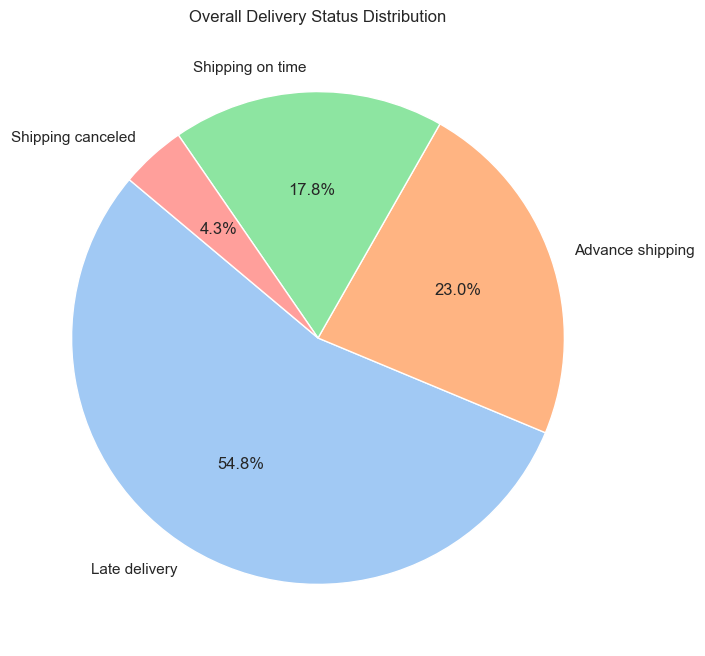

In [117]:
# 1. Delivery Status Distribution (Pie Chart)
plt.clf()
plt.figure(figsize=(8,8))
df['delivery_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140)
plt.title('Overall Delivery Status Distribution')
plt.ylabel('')
plt.savefig('v1_delivery_pie.png')

<Figure size 640x480 with 0 Axes>

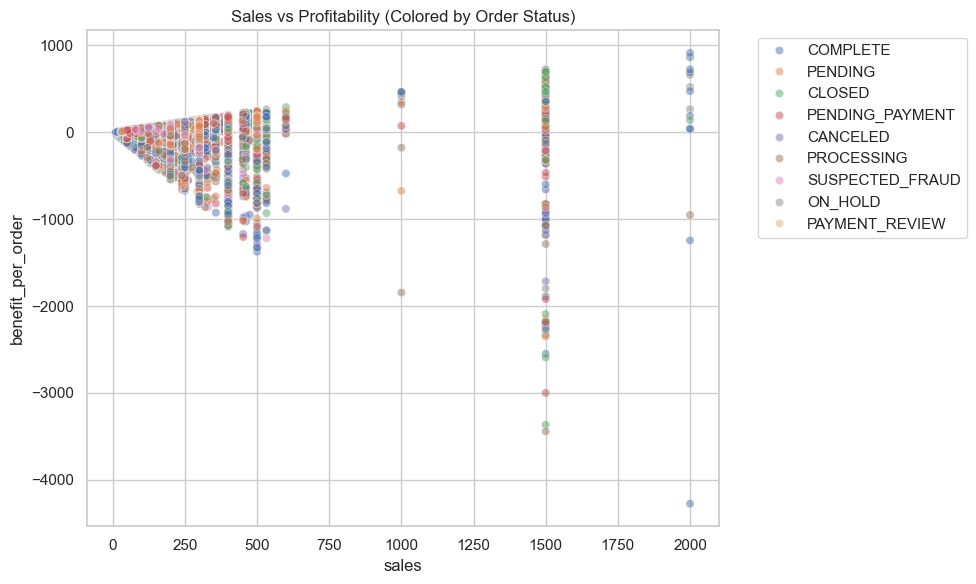

In [118]:
# 2. Sales vs Profit (Scatter with Fraud Hue)
plt.clf()
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sales', y='benefit_per_order', hue='order_status', alpha=0.5)
plt.title('Sales vs Profitability (Colored by Order Status)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('v2_sales_profit_scatter.png')

/var/folders/8t/8syr23f147d2n68c6mk7kddr0000gn/T/ipykernel_39791/902566166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_sales.values, y=top_10_sales.index, palette='magma')


<Figure size 640x480 with 0 Axes>

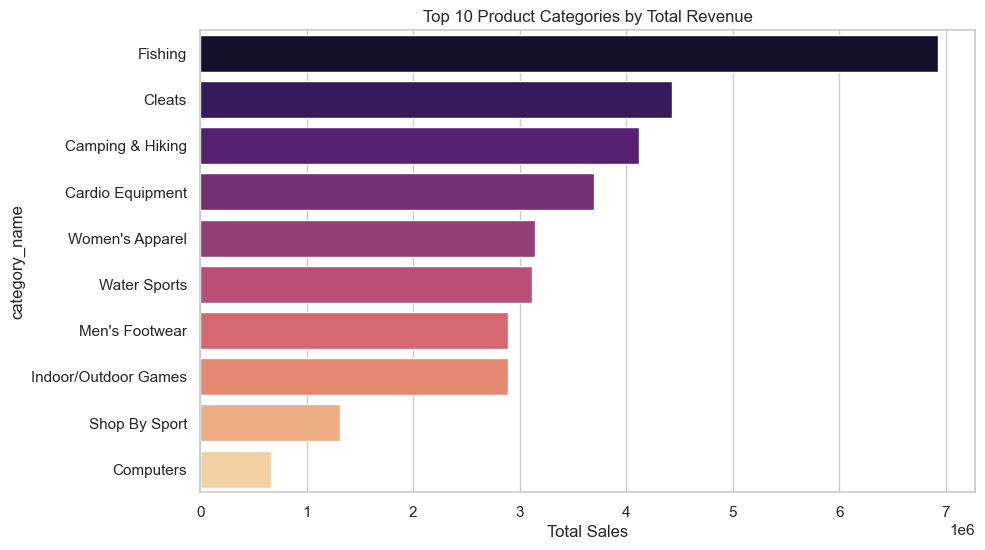

In [119]:
# 3. Top 10 Product Categories by Revenue
plt.clf()
plt.figure(figsize=(10,6))
top_10_sales = df.groupby('category_name')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_10_sales.values, y=top_10_sales.index, palette='magma')
plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('Total Sales')
plt.savefig('v3_top_categories_sales.png')

/var/folders/8t/8syr23f147d2n68c6mk7kddr0000gn/T/ipykernel_39791/2676635686.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='shipping_mode', y='days_for_shipping_(real)', palette='Set2')


<Figure size 640x480 with 0 Axes>

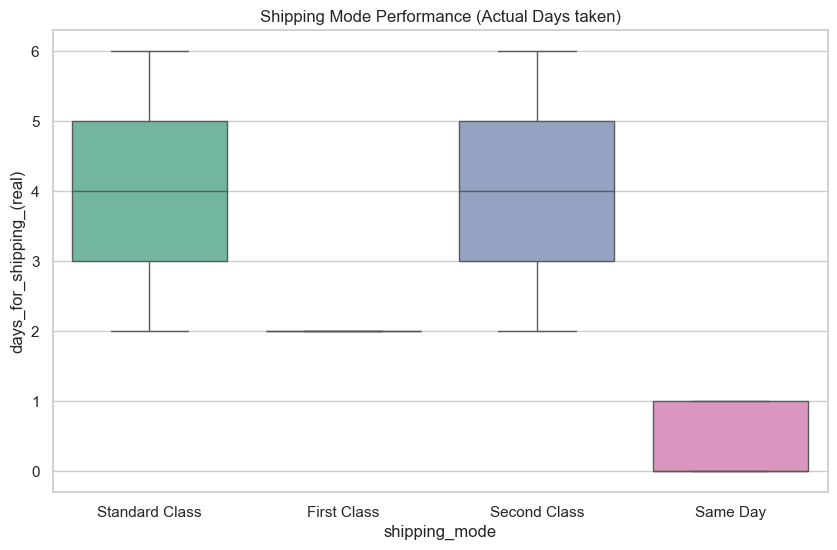

In [120]:
# 4. Shipping Mode vs Actual Shipping Days (Boxplot)
plt.clf()
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='shipping_mode', y='days_for_shipping_(real)', palette='Set2')
plt.title('Shipping Mode Performance (Actual Days taken)')
plt.savefig('v4_shipping_mode_boxplot.png')

/var/folders/8t/8syr23f147d2n68c6mk7kddr0000gn/T/ipykernel_39791/2635512581.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales.values, palette='viridis')


<Figure size 640x480 with 0 Axes>

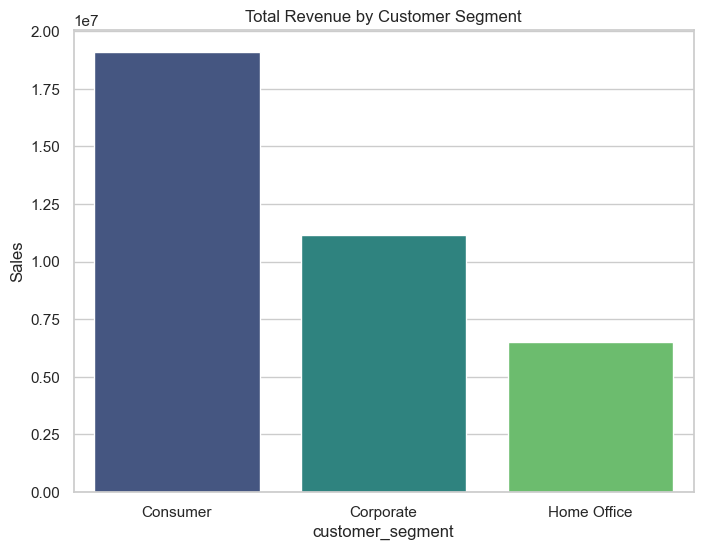

In [121]:
# 5. Revenue by Customer Segment
plt.clf()
plt.figure(figsize=(8,6))
segment_sales = df.groupby('customer_segment')['sales'].sum().sort_values(ascending=False)
sns.barplot(x=segment_sales.index, y=segment_sales.values, palette='viridis')
plt.title('Total Revenue by Customer Segment')
plt.ylabel('Sales')
plt.savefig('v5_segment_revenue.png')

/var/folders/8t/8syr23f147d2n68c6mk7kddr0000gn/T/ipykernel_39791/1043328773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='order_day_of_week', order=day_order, palette='coolwarm')


<Figure size 640x480 with 0 Axes>

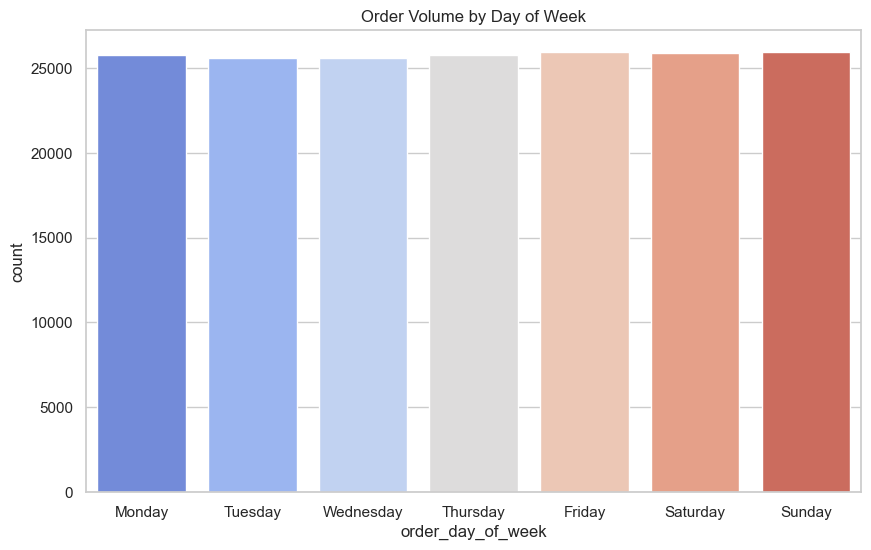

In [122]:
# 6. Order Volume by Day of the Week
plt.clf()
plt.figure(figsize=(10,6))
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sns.countplot(data=df, x='order_day_of_week', order=day_order, palette='coolwarm')
plt.title('Order Volume by Day of Week')
plt.savefig('v6_weekday_volume.png')

<Figure size 640x480 with 0 Axes>

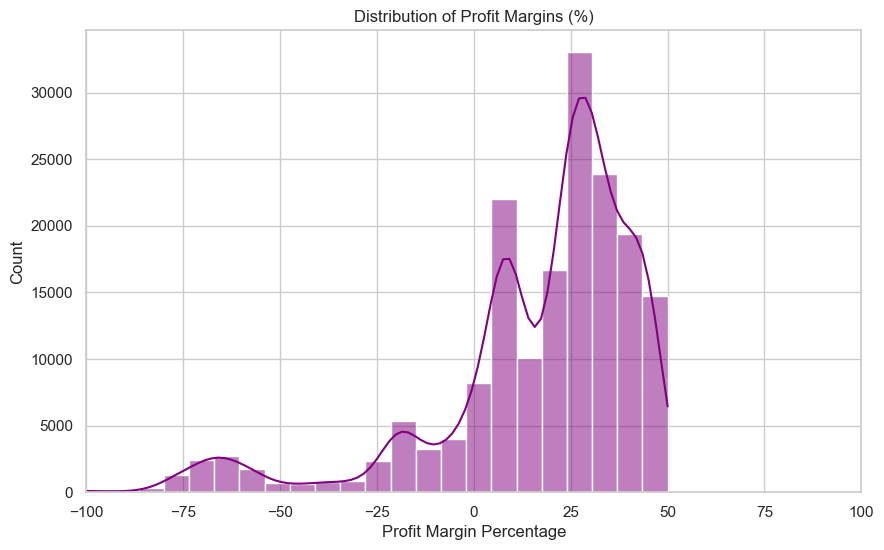

In [123]:
# 7. Profit Margin Distribution
plt.clf()
plt.figure(figsize=(10,6))
sns.histplot(df['profit_margin_pct'], bins=50, kde=True, color='purple')
plt.title('Distribution of Profit Margins (%)')
plt.xlabel('Profit Margin Percentage')
plt.xlim(-100, 100) # Clipping for better view of common margins
plt.savefig('v7_profit_margin_dist.png')

/var/folders/8t/8syr23f147d2n68c6mk7kddr0000gn/T/ipykernel_39791/1831144074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='order_status', order=df['order_status'].value_counts().index, palette='magma')


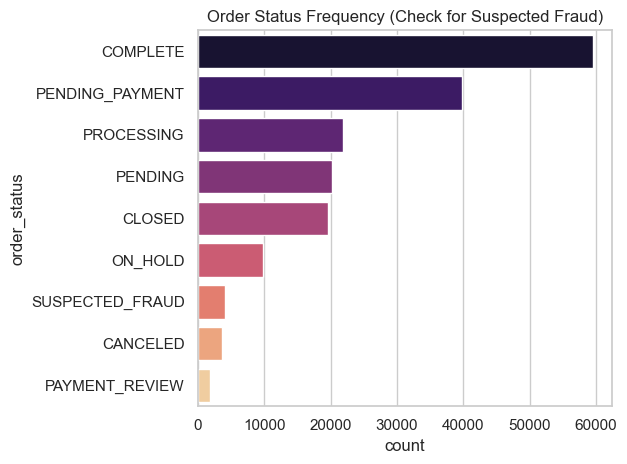

In [125]:
# 8. COUNT PLOT: Order Status (Focus on Fraud)
plt.clf()
sns.countplot(data=df, y='order_status', order=df['order_status'].value_counts().index, palette='magma')
plt.title('Order Status Frequency (Check for Suspected Fraud)')
plt.tight_layout()
plt.savefig('v8_order_status.png')

/var/folders/8t/8syr23f147d2n68c6mk7kddr0000gn/T/ipykernel_39791/2346791231.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket')


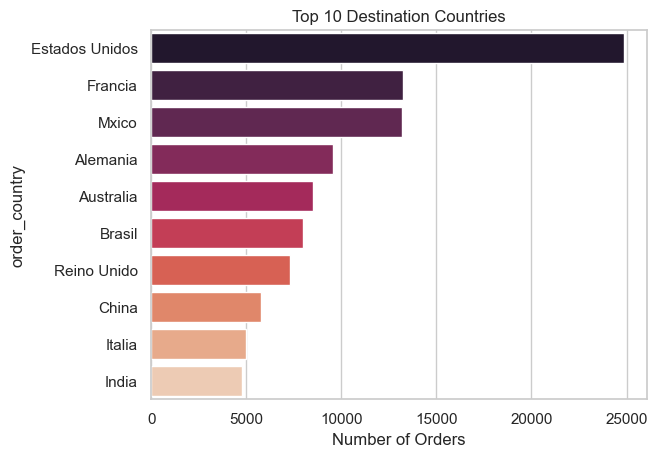

In [126]:
# 9. BAR CHART: Top 10 Countries by Order Volume
plt.clf()
top_countries = df['order_country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket')
plt.title('Top 10 Destination Countries')
plt.xlabel('Number of Orders')
plt.savefig('v9_top_countries.png')

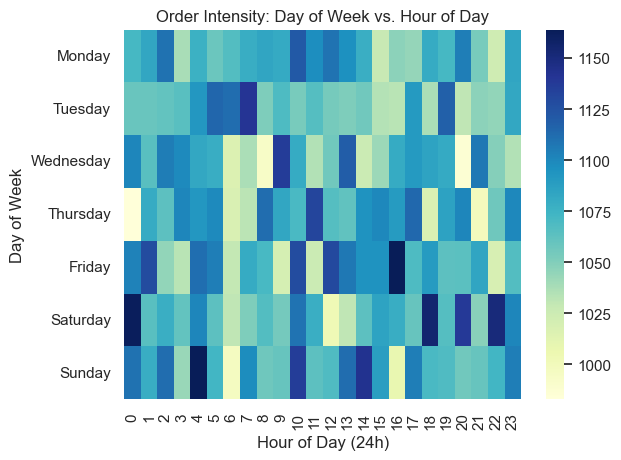

In [127]:
# 10. HEATMAP: Order Intensity by Day and Hour
plt.clf()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = df.pivot_table(index='order_day_of_week', columns='order_hour', values='order_id', aggfunc='count').reindex(day_order)
sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title('Order Intensity: Day of Week vs. Hour of Day')
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Day of Week')
plt.savefig('v10_order_heatmap.png')

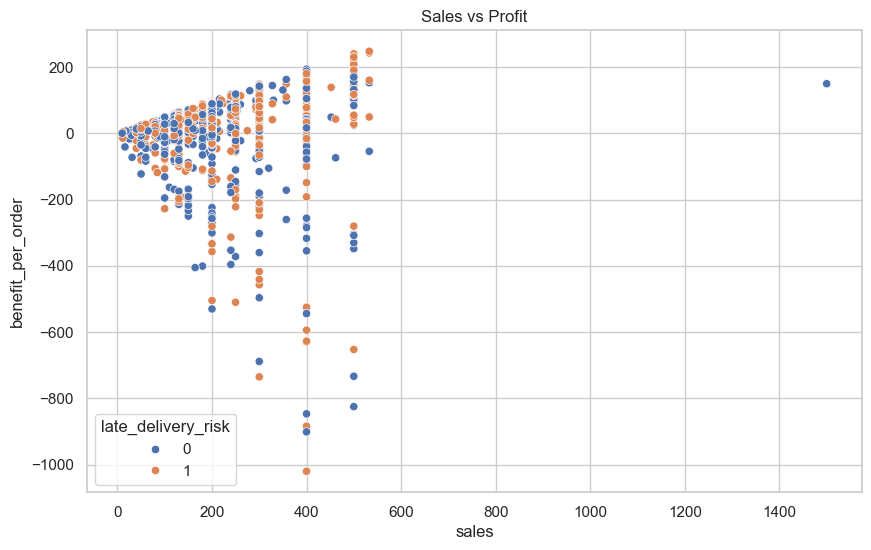

<Figure size 640x480 with 0 Axes>

In [128]:
# 11. Sales vs Profit Scatter
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(2000), x='sales', y='benefit_per_order', hue='late_delivery_risk')
plt.title('Sales vs Profit')
plt.show()
plt.savefig('v11_sales_profit_late.png')

DATA TO DATABASE

In [132]:
import pandas as pd
from sqlalchemy import create_engine, text

# 1. Credentials
username = "dhruvsingh"
password = "10012007" 
host = "localhost"
port = "5432"
database = "supply_chain_analytics"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# 2. Drop the old tables to clean the workspace
with engine.connect() as conn:
    conn.execution_options(isolation_level="AUTOCOMMIT")
    conn.execute(text("DROP TABLE IF EXISTS customer;"))
    conn.execute(text("DROP TABLE IF EXISTS supply_chain_master;"))
    print("🧹 Cleaned up! Old tables deleted.")

# 3. Upload to the final single table: 'orders'
try:
    print("🚀 Uploading data to final 'orders' table...")
    df.to_sql(
        'orders', 
        engine, 
        if_exists='replace', 
        index=False, 
        chunksize=10000, 
        method='multi'
    )
    print("✅ Success! You now have exactly ONE table named 'orders'.")
except Exception as e:
    print(f"❌ Error during upload: {e}")

🧹 Cleaned up! Old tables deleted.
🚀 Uploading data to final 'orders' table...
✅ Success! You now have exactly ONE table named 'orders'.
